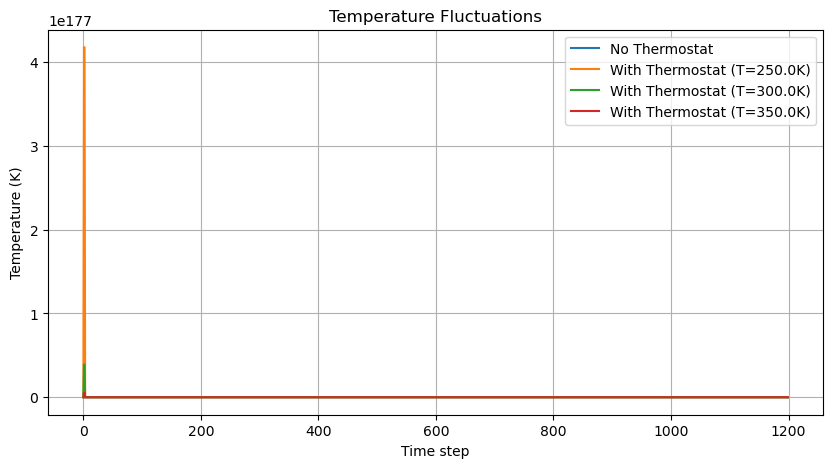

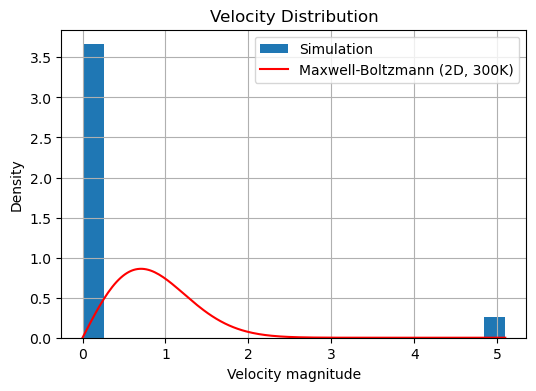

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
L = 15.0
steps = 1200
dt = 0.005
m = 1.2
sigma = 3.8
epsilon = 0.4
kB = 0.001987
temperatures = [250.0, 300.0, 350.0]

def pbc(x):
    return x % L

def forces(coords):
    F = np.zeros_like(coords)
    E = 0.0
    for i in range(N):
        for j in range(i+1, N):
            dx = coords[i,0] - coords[j,0]
            dy = coords[i,1] - coords[j,1]
            dx -= L * np.round(dx / L)
            dy -= L * np.round(dy / L)
            r = np.sqrt(dx*dx + dy*dy)
            if r > 0:
                sr6 = (sigma/r)**6
                sr12 = sr6*sr6
                E += 4*epsilon*(sr12 - sr6)
                f = 24*epsilon*(2*sr12 - sr6)/r**2
                F[i,0] += f*dx
                F[i,1] += f*dy
                F[j,0] -= f*dx
                F[j,1] -= f*dy
    return F, E

coords = np.random.uniform(0, L, (N, 2))
velocities = np.random.normal(0, 1, (N, 2))

energies_no_thermo = []
temps_no_thermo = []
F, E_pot = forces(coords)

for step in range(steps):
    coords = pbc(coords + velocities*dt + 0.5*F/m*dt**2)
    F_new, E_pot = forces(coords)
    velocities = velocities + 0.5*(F + F_new)/m*dt
    F = F_new
    E_kin = 0.5*m*np.sum(velocities**2)
    T = (2/3)*(E_kin/(N*kB))
    temps_no_thermo.append(T)
    energies_no_thermo.append(E_pot + E_kin)

temps_with_thermo = {T: [] for T in temperatures}
energies_with_thermo = {T: [] for T in temperatures}
velocities_with_thermo = {T: np.copy(velocities) for T in temperatures}
coords_with_thermo = {T: np.copy(coords) for T in temperatures}

for T in temperatures:
    coords = np.copy(coords_with_thermo[T])
    velocities = np.copy(velocities_with_thermo[T])
    F, E_pot = forces(coords)
    for step in range(steps):
        coords = pbc(coords + velocities*dt + 0.5*F/m*dt**2)
        F_new, E_pot = forces(coords)
        velocities = velocities + 0.5*(F + F_new)/m*dt
        F = F_new
        E_kin = 0.5*m*np.sum(velocities**2)
        T_current = (2/3)*(E_kin/(N*kB))
        scale = np.sqrt(T / T_current)
        velocities *= scale  # rescale velocities
        E_kin = 0.5*m*np.sum(velocities**2)  # recalc kinetic energy
        temps_with_thermo[T].append(T_current)
        energies_with_thermo[T].append(E_pot + E_kin)

plt.figure(figsize=(10,5))
plt.plot(temps_no_thermo, label="No Thermostat")
for T in temperatures:
    plt.plot(temps_with_thermo[T], label=f"With Thermostat (T={T}K)")
plt.xlabel("Time step")
plt.ylabel("Temperature (K)")
plt.title("Temperature Fluctuations")
plt.legend()
plt.grid(True)
plt.show()

v_mags = np.sqrt(np.sum(velocities**2, axis=1))
plt.figure(figsize=(6,4))
plt.hist(v_mags, bins=20, density=True, label="Simulation")
v = np.linspace(0, max(v_mags), 200)
T_ref = 300
MB = (m/(kB*T_ref)) * v * np.exp(-m*v**2/(2*kB*T_ref))
plt.plot(v, MB, 'r-', label=f"Maxwell-Boltzmann (2D, {T_ref}K)")
plt.xlabel("Velocity magnitude")
plt.ylabel("Density")
plt.title("Velocity Distribution")
plt.legend()
plt.grid(True)
plt.show()